## Interrupt Before Tool Calling

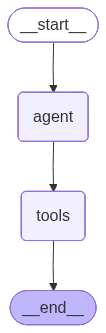

In [2]:
from typing import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langchain.tools import tool
from langgraph.types import interrupt, Command
from langgraph.prebuilt import ToolNode
from langchain_aws import ChatBedrockConverse

# --- Define State ---
class AgentState(TypedDict):
    messages: list[dict]

# --- Define Tool: Send Audit Report ---
@tool
def send_audit_report(client_name: str, auditor_email: str, summary: str):
    """Send a client's financial audit summary to the assigned auditor."""
    # Pause before sending sensitive report for human approval
    response = interrupt({
        "action": "send_audit_report",
        "client_name": client_name,
        "auditor_email": auditor_email,
        "summary": summary,
        "message": f"Approve sending the financial audit summary of {client_name} to {auditor_email}?"
    })

    if response.get("action") == "approve":
        print(f"\n[Audit Report Sent] client={client_name}, auditor={auditor_email}")
        print(f"Summary: {summary}\n")
        return f" Audit report sent to {auditor_email}"

    print("\n[Action Cancelled]\n")
    return " Sending of audit report cancelled"

# --- LLM Setup ---
# --- LLM Setup ---
llm = ChatBedrockConverse(model_id = "cohere.command-r-plus-v1:0")
model = llm.bind_tools([send_audit_report])


# --- Define Agent Node ---
def agent_node(state: AgentState):
    result = model.invoke(state["messages"])
    return {"messages": state["messages"] + [result]}

# --- Tool Execution Node ---
tool_node = ToolNode([send_audit_report])

# --- Build Graph ---
builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_edge(START, "agent")
builder.add_edge("agent", "tools")
builder.add_edge("tools", END)

# --- Compile with In-Memory Checkpointing ---
graph = builder.compile(checkpointer=MemorySaver())
builder.compile(checkpointer=MemorySaver())


In [3]:
# --- Config ---
config = {"configurable": {"thread_id": "audit-review-thread"}}

# --- Step 1: Initial Invocation ---
initial = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Send the quarterly financial audit summary for ABC Corp "
                    "to auditor rita@financeaudit.com with the note: "
                    "'Revenue up by 8%, but operational costs increased by 5%.'"
                ),
            }
        ]
    },
    config=config,
)

# --- Interrupt Handling ---
if "__interrupt__" in initial:
    print("\n--- INTERRUPT TRIGGERED ---")
    print(initial["__interrupt__"])
else:
    print("\nNo interrupt occurred. The LLM might not have triggered the tool call.")


--- INTERRUPT TRIGGERED ---
[Interrupt(value={'action': 'send_audit_report', 'client_name': 'ABC Corp', 'auditor_email': 'rita@financeaudit.com', 'summary': 'Revenue up by 8%, but operational costs increased by 5%.', 'message': 'Approve sending the financial audit summary of ABC Corp to rita@financeaudit.com?'}, id='8969c2eb8c027114ce7429d67fab95eb')]


In [4]:
resumed = graph.invoke(Command(resume={"action": "approve"}), config=config)


[Audit Report Sent] client=ABC Corp, auditor=rita@financeaudit.com
Summary: Revenue up by 8%, but operational costs increased by 5%.



In [5]:
print(resumed)

{'messages': [ToolMessage(content=' Audit report sent to rita@financeaudit.com', name='send_audit_report', tool_call_id='tooluse_iZZAsFVuR-Om-5fzCs6FgQ')]}
